In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.random.manual_seed(42)

# Use GPU if available
DEFAULT_DEVICE = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print(f"using {DEFAULT_DEVICE} as device")

/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


using xpu as device


# Generate some signal

We first use `ttpd` to generate some signal data. We populate one signal channel (cauchy distribution) and one background channel (uniform distribution).

In [2]:
from ttpd.generator import SimulateFactory
from ttpd.kinematics import invariant_mass_from_ptphieta, mZ0

# build the simulator
factory = SimulateFactory.create(device=DEFAULT_DEVICE)
sim = factory.create_simulator(generation_seed=1137, smear_seed=1237)

In [3]:
#create signal and background
num_signal = 10_000
num_bkrd = 2_000

signal_prior = torch.distributions.Cauchy(loc=mZ0, scale=.1)

theta = torch.empty((num_signal+num_bkrd,2), dtype=torch.float32)
theta[:num_signal,0] = signal_prior.sample((num_signal,))
theta[:num_signal,1] = torch.zeros_like(theta[:num_signal,0])

q05, q95 = torch.quantile(theta[:num_signal,0], 
                          torch.from_numpy(np.asarray([.05,.95], dtype=np.float32))
                         )

#we cannot allow negative masses, long tails of cauchy sometimes sample below 0. 
lo,hi = float(max(q05.numpy(),0.)), float(q95)
bkrd_prior = torch.distributions.Uniform(low=lo, high=hi)

theta[num_signal:,0] = bkrd_prior.sample((num_bkrd,))
theta[num_signal:,1] = torch.ones_like(theta[num_signal:,0])

For visual quality control, we plot the generated masses which fall into $\vartheta_0$.

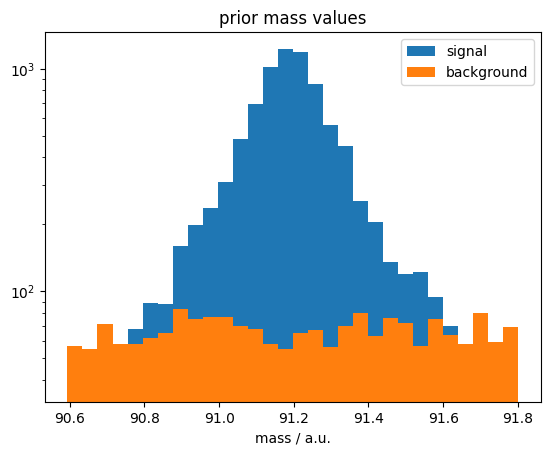

In [4]:
plt.hist(theta[:num_signal,0],bins=30, range=(lo,hi), label="signal")
plt.hist(theta[num_signal:,0],bins=30, range=(lo,hi), label="background")
plt.title("prior mass values")
plt.xlabel("mass / a.u.")
plt.yscale("log")
plt.legend()
plt.show()

We perform simulations. This takes the input invariant masses and constructs the 4-vectors of 2 daughter particles.

In [5]:
x = sim(theta)
print(x.shape, x.dtype)

torch.Size([12000, 8]) torch.float32


## Training an MNPE density estimator

The `sbi` toolbox is capable of learning a density estimator, which can estimate $p(\vartheta|x)$, i.e. the posterior density of $vartheta$ given the observed data $x$.

In [6]:
# Now do MNPE demo
# https://sbi.readthedocs.io/en/latest/reference/_autosummary/sbi.inference.MNPE.html
from sbi.inference import MNPE

num_sims = theta.shape[0]
theta[:,1] = theta[:,1].int() #convert to int to signal categorical column

inference = MNPE(device=DEFAULT_DEVICE)
_ = inference.append_simulations(theta.to(DEFAULT_DEVICE), x.to(DEFAULT_DEVICE)).train()

/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Data x has device 'xpu:0'. Moving x to the data_device 'xpu'. Training will proceed on device 'xpu'.
  theta, x = validate_theta_and_x(
/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Parameters theta has device 'xpu:0'. Moving theta to the data_device 'xpu'. Training will proceed on device 'xpu'.
  theta, x = validate_theta_and_x(


/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 3, 4, 7] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/sbi/neural_nets/net_builders/mixed_nets.py:280: UserWarning: The mixed neural density estimator assumes that inferred variable contains continuous data in the first n-k columns and categorical data in the last k columns.
  return _build_mixed_density_estimator(
/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/sbi/neural_nets/net_builders/mixed_nets.py:177: UserWarning: Inferring num_categories from batch_x. Ensure all categories are present.
  discrete_net = build_categoricalmassestimator(


 Training neural network. Epochs trained: 1

 Training neural network. Epochs trained: 2

...

 Training neural network. Epochs trained: 180

 Training neural network. Epochs trained: 181

 Training neural network. Epochs trained: 182

 Training neural network. Epochs trained: 183

 Neural network successfully converged after 184 epochs.

In [7]:

posterior = inference.build_posterior()

/home/steinb95/development/sbi-dev/toyMC-for-mnpe/py312-xpu/lib/python3.12/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


## Validation data

In order to draw independent conclusions, let's sample some more data and use that to check the validity of our trained density estimator.

In [8]:
# validation data
num_val_signal = 150
num_val_backgd = 50
num_val = num_val_backgd + num_val_signal

theta_val = torch.zeros((num_val,2))
theta_val[:num_val_signal,0] = signal_prior.sample((num_val_signal,))
theta_val[:num_val_signal,1] = torch.zeros_like(theta_val[:num_val_signal,0])

theta_val[num_val_signal:,0] = bkrd_prior.sample((num_val_backgd,))
theta_val[num_val_signal:,1] = torch.ones_like(theta_val[num_val_signal:,0])

In [9]:
x_val = sim(theta_val)

  0%|                                                                                                                                 | 0/200 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1789.82it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1779.41it/s]

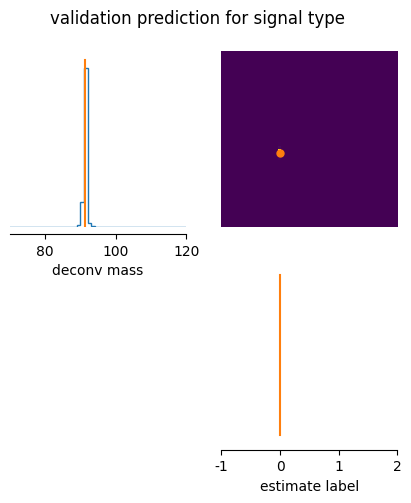

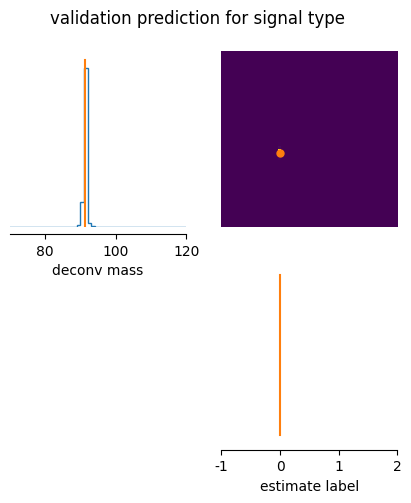

In [10]:
from sbi.analysis import pairplot
from sbi.analysis.plotting_classes import HistDiagOptions

first_theta = theta_val[:1,...]
first_x = x_val[:1,...]

num_posterior_samples = 200
samples = posterior.sample((num_posterior_samples,),x=first_x)

fig, axes = pairplot(
    samples.cpu(),
    limits=[[70,120],[-1,2]],
    figsize=(5, 5),
    points=first_theta.cpu(),
    labels=["deconv mass","estimate label"],
    diag_kwargs=HistDiagOptions(
        mpl_kwargs={
            "bins": np.arange(62,122,1),
        }
    )
)
fig.suptitle("validation prediction for signal type")
fig

This single item from the validation set comes out right ontop of the truth. The problem appears to be very easy for MNPE. Let's try the same with a background event. Here the challenge is to fit a uniform distribution.

  0%|                                                                                                                                 | 0/200 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 19711.46it/s]

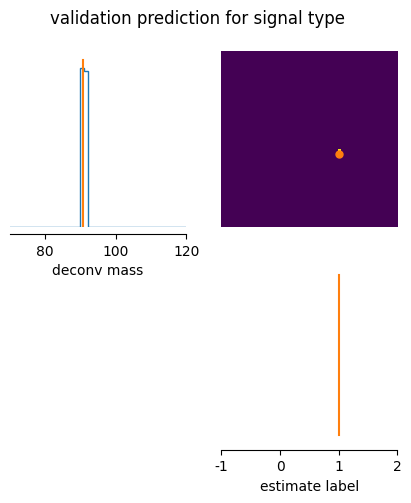

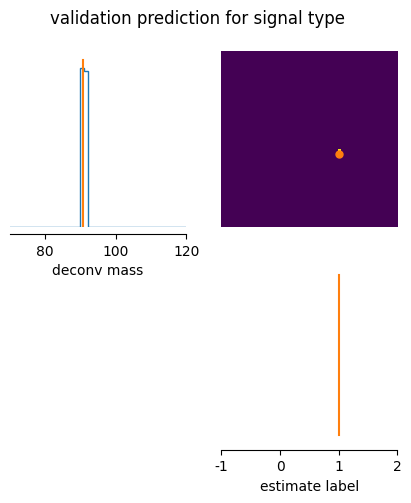

In [11]:
last_theta = theta_val[-1:,...]
last_x = x_val[-1:,...]

samples_ = posterior.sample((num_posterior_samples,),x=last_x)

fig_, axes_ = pairplot(
    samples_.cpu(),
    limits=[[70,120],[-1,2]],
    figsize=(5, 5),
    points=last_theta.cpu(),
    labels=["deconv mass","estimate label"],
    diag_kwargs=HistDiagOptions(
        mpl_kwargs={
            "bins": np.arange(62,122,1),
        }
    )
)
fig_.suptitle("validation prediction for signal type")
fig_

## Posterior Checks

[TBA](https://sbi.readthedocs.io/en/stable/advanced_tutorials/10_diagnostics_posterior_predictive_checks.html)

## Model Critique

[TBA](https://sbi.readthedocs.io/en/stable/advanced_tutorials/11_diagnostics_simulation_based_calibration.html#posterior-calibration-with-tarp-lemos-et-al-2023)